# 🏥 CariSurg MedTech Pathways — Week 0 Final Notebook
## Basic Data Visualisation with matplotlib
**Mercer General Hospital | Clinical AI & Innovation Unit**

---
A compilation of everything that was taught in Tutorials this Week 0.

---
### What was covered in this notebook:
Data Cleaning and Visualization. Created additional visualisations using the cleaned Mercer General Emergency Department dataset. The goal was to produce plots that were clinically meaningful, clearly labelled, and supported by appropriate reference lines.


## 1. Setup — Load and Clean

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


## 2. Visualization Section:



A table of numbers is hard to reason about. A plot reveals patterns instantly.

In clinical data science, visualisation serves three purposes:
1. **Quality check** — does the data look like what we expect?
2. **Pattern discovery** — are there relationships between variables?
3. **Communication** — can a nurse or doctor understand our finding in 10 seconds?

The rule for this programme: **every plot must answer a specific clinical question.**
If you cannot state the question, you should not make the plot.


## 3. Bar Plots — Categorical Columns

**Clinical question: What is the gender breakdown of patients in this dataset?**

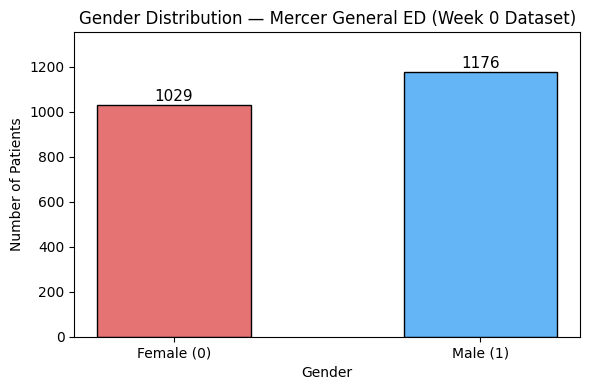

Saved: gender_distribution.png


In [ ]:
# Bar plot: Gender distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['Gender'].value_counts().sort_index()
bars = ax.bar(['Female (0)', 'Male (1)'], counts.values,
              color=['#E57373', '#64B5F6'], edgecolor='black', width=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11)

ax.set_title('Gender Distribution — Mercer General ED (Week 0 Dataset)', fontsize=12)
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gender_distribution.png")

## 4. Histograms — Distributions

**Clinical question: How are GCS scores distributed across our patients — are most patients alert, or are there many with reduced consciousness?**

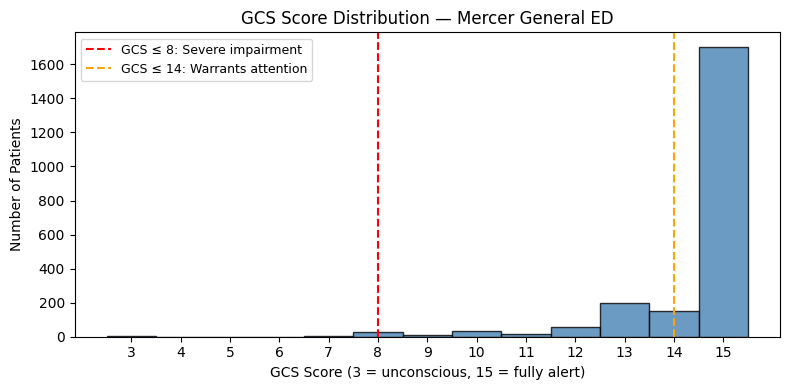

Saved: gcs_histogram.png


In [ ]:
# Histogram: GCS distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['GCS'], bins=range(3, 17), edgecolor='black',
        color='steelblue', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5,
           label='GCS ≤ 8: Severe impairment')
ax.axvline(x=14, color='orange', linestyle='--', linewidth=1.5,
           label='GCS ≤ 14: Warrants attention')

ax.set_title('GCS Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('GCS Score (3 = unconscious, 15 = fully alert)')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(3, 16))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gcs_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gcs_histogram.png")

**[TUTOR NOTE — key teaching point]**
The vertical reference lines are not decoration — they carry clinical meaning.
GCS ≤ 8 is the threshold for intubation consideration in many protocols.
GCS ≤ 14 triggers additional monitoring at Mercer.

Ask: "What does it tell us that most patients cluster at 15?"
(It suggests most patients arriving at this ED are conscious — consistent with a mixed-acuity emergency department.)


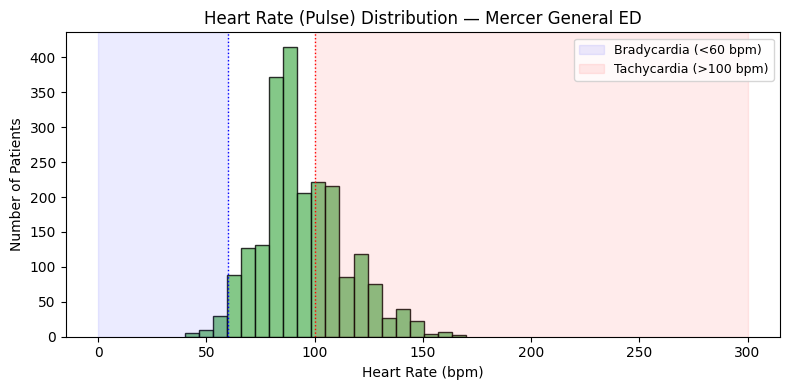

Saved: pulse_histogram.png


In [ ]:
# Histogram: Pulse (heart rate) distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['pulse'], bins=20, edgecolor='black', color='#66BB6A', alpha=0.8)

# Clinical reference zones
ax.axvspan(0, 60, alpha=0.08, color='blue', label='Bradycardia (<60 bpm)')
ax.axvspan(100, 300, alpha=0.08, color='red', label='Tachycardia (>100 bpm)')
ax.axvline(x=60, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=100, color='red', linestyle=':', linewidth=1)

ax.set_title('Heart Rate (Pulse) Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Heart Rate (bpm)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pulse_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_histogram.png")

## 5. Scatter Plots — Two-Variable Relationships

**Clinical question: Is there a relationship between systolic and diastolic blood pressure in these patients? Does it follow what physiology would predict?**

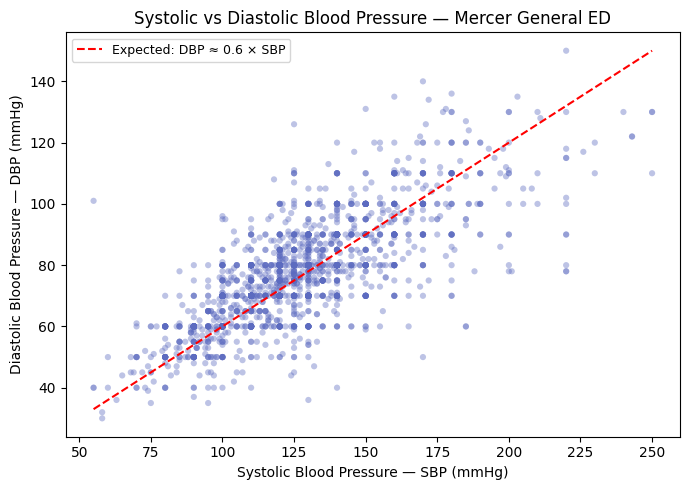

Saved: sbp_vs_dbp.png


In [ ]:
# Scatter plot: SBP vs DBP
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['SBP'], df['DBP'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Add a trend reference:

sbp_range = np.linspace(df['SBP'].min(), df['SBP'].max(), 100)
ax.plot(sbp_range, sbp_range * 0.6, color='red', linestyle='--',
        linewidth=1.5, label='Expected: DBP ≈ 0.6 × SBP')

ax.set_title('Systolic vs Diastolic Blood Pressure — Mercer General ED', fontsize=12)
ax.set_xlabel('Systolic Blood Pressure — SBP (mmHg)')
ax.set_ylabel('Diastolic Blood Pressure — DBP (mmHg)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sbp_vs_dbp.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sbp_vs_dbp.png")

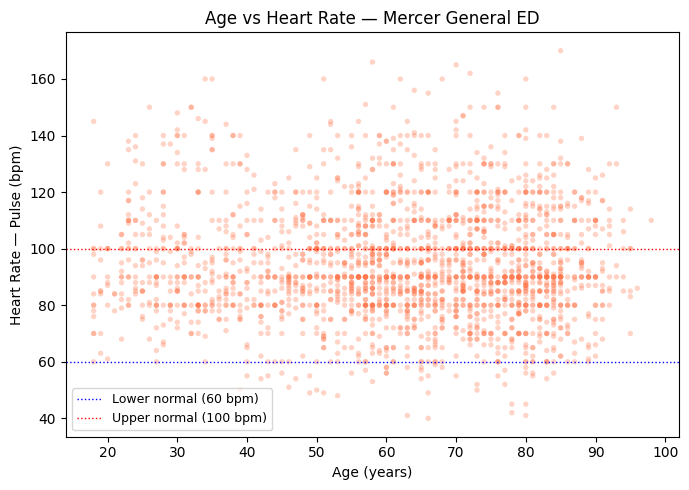

Saved: age_vs_pulse.png


In [ ]:
# Scatter plot: Age vs Pulse — does age affect resting heart rate in ED patients?
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['pulse'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.set_title('Age vs Heart Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — Pulse (bpm)')

# Add clinical reference lines
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1, label='Lower normal (60 bpm)')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Upper normal (100 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_pulse.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_pulse.png")

## 6. Box Plots — Spotting Remaining Outliers

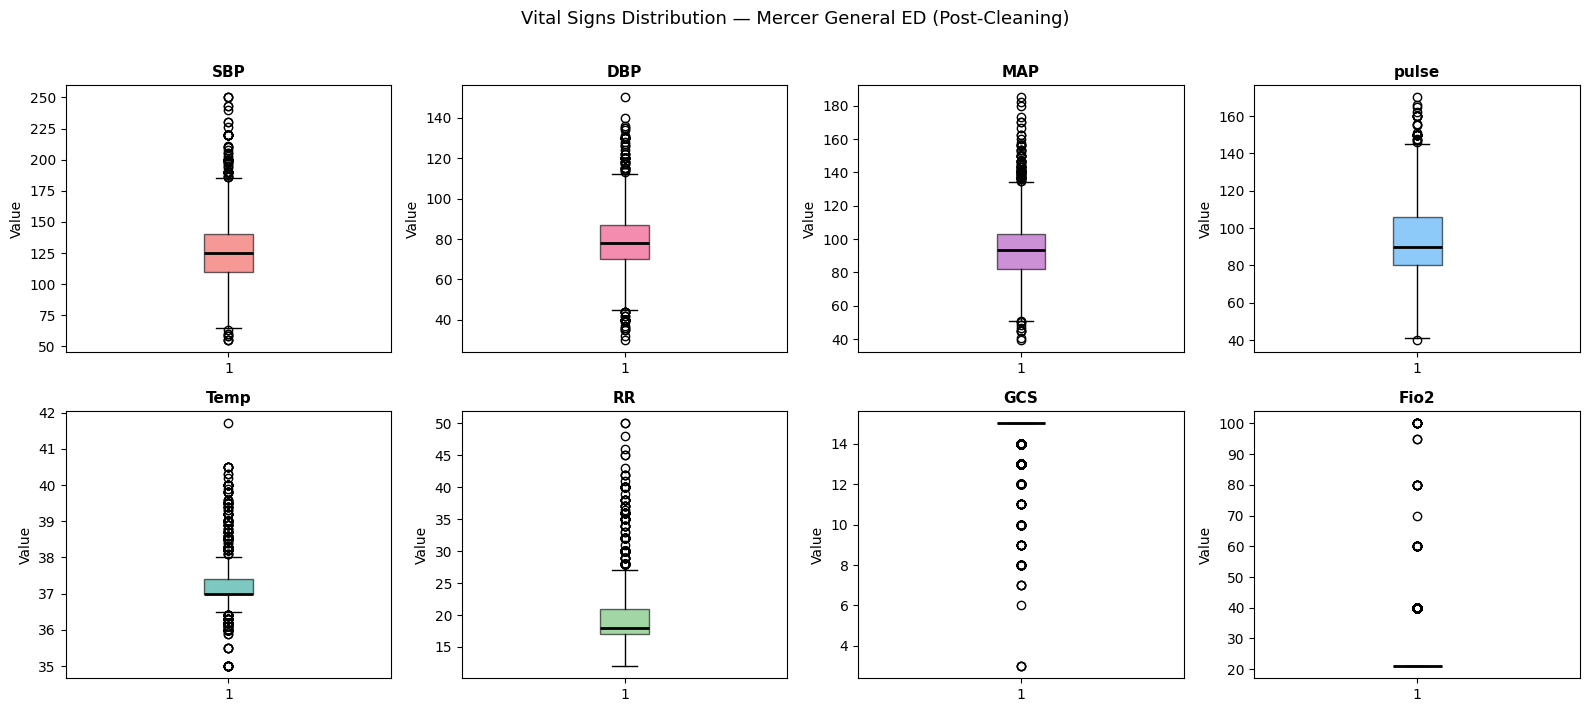

Saved: vitals_boxplots.png


In [ ]:
# Box plots for all numeric vitals — side by side for a quick overview
vitals = ['SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'GCS', 'Fio2']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = ['#EF5350','#EC407A','#AB47BC','#42A5F5','#26A69A','#66BB6A','#FFA726','#8D6E63']

for i, (vital, col) in enumerate(zip(vitals, colors)):
    axes[i].boxplot(df[vital].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(vital, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Vital Signs Distribution — Mercer General ED (Post-Cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vitals_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: vitals_boxplots.png")

## 7. Saving and Posting Plots

In [ ]:
# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  age_vs_pulse.png                    (113 KB)
  gcs_histogram.png                   (34 KB)
  gender_distribution.png             (23 KB)
  pulse_histogram.png                 (35 KB)
  sbp_vs_dbp.png                      (96 KB)
  vitals_boxplots.png                 (79 KB)


## 8. Student Challenge — Build Your Own Plot

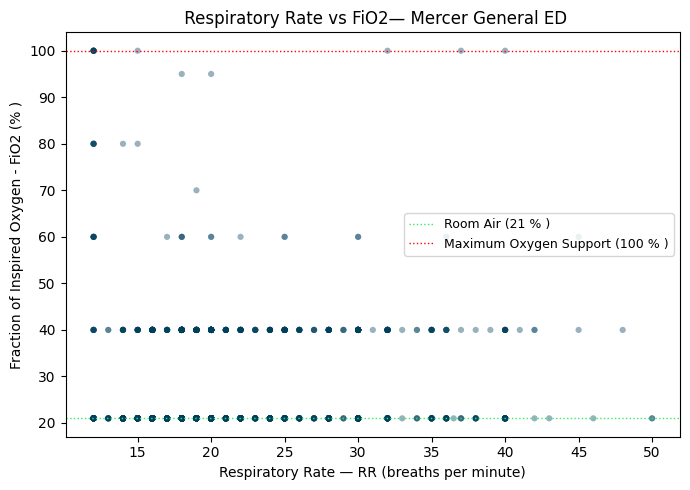

Saved: my_plot.png


In [ ]:
# ── YOUR TURN ────────────────────────────────────────────────
# Pick any two variables from the dataset and create a meaningful plot.
# Before you code, answer these questions in a comment:
#
# 1. What is the clinical question this plot answers?
# 2. What type of plot is appropriate (histogram, scatter, bar, box)?
# 3. What reference lines or annotations would add clinical meaning?

# Your code here:

# ---PLOT 1-----
# Scatter Plot of FiO2 vs Respiratory Rate (RR)
# My question is: Does the Respiratory Rate (the number of breaths that are taken per minute)
################  have an effect on the FiO2 measured in the patients in the ED?

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['RR'], df['Fio2'],
                     alpha=0.4, s=20, color='#003f5c', edgecolors='none')
# alpha determines the tranasparency of the points

# Add the clinical references:
# clinical reference lines of Lower Bound of FiO2 (Room Air) and the Maximum Oxygen Support
ax.axhline(y=21, color='#34eb67', linestyle=':', linewidth=1, label='Room Air (21 % )')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Maximum Oxygen Support (100 % )')
ax.legend(fontsize=9)


ax.set_title(' Respiratory Rate vs FiO2— Mercer General ED', fontsize=12)
ax.set_ylabel('Fraction of Inspired Oxygen - FiO2 (% )')
ax.set_xlabel('Respiratory Rate — RR (breaths per minute)')
ax.legend(fontsize=9)

#print(df['Fio2'].value_counts())
#print(df['RR'].describe())

plt.tight_layout()
plt.savefig('my_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: my_plot.png")




# plt.savefig('my_plot.png', dpi=100, bbox_inches='tight')
# plt.show()

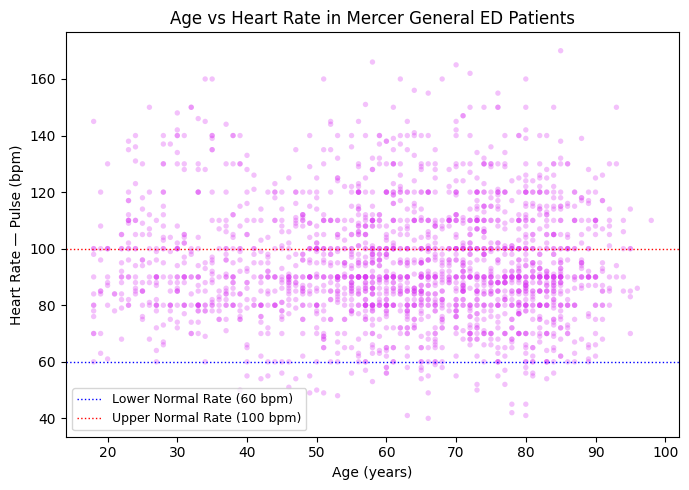

Saved: age_vs_pulse2.png


In [ ]:
# ---PLOT 2-----
# # Scatter plot: Age vs Pulse
# My question is: Does the age affect the resting heart rate in ED patients?


fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['pulse'],
           alpha=0.3, s=15, color='#d933f2', edgecolors='none')

ax.set_title('Age vs Heart Rate in Mercer General ED Patients', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — Pulse (bpm)')

# Add clinical reference lines
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1, label='Lower Normal Rate (60 bpm)')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Upper Normal Rate (100 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_pulse2.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_pulse2.png")

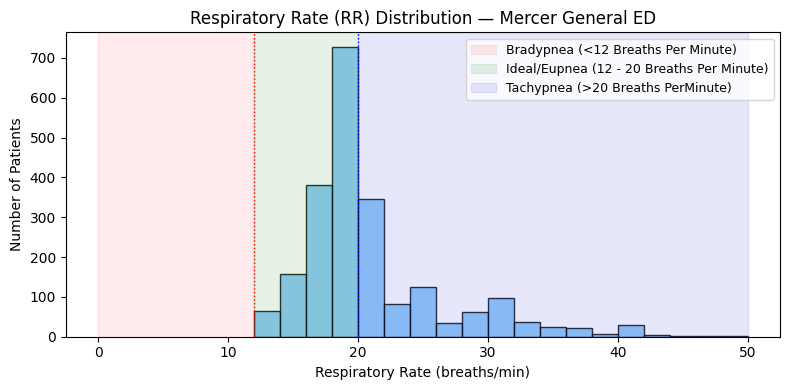

Saved: my_plot2.png


In [ ]:
#---PLOT 3-----
# Histogram: Respiratory Rate Distribution
# My question is: What is the Distribution of the Respiratory Rates in relation to the
################# abnormal Respiratory Rates in the ED Patients?

fig, ax = plt.subplots(figsize=(8, 4))
# Calculating the bins
min_rr = df['RR'].min()
max_rr = df['RR'].max()

bins = np.arange(min_rr, max_rr + 2, 2)

ax.hist(df['RR'], bins=bins, edgecolor='black', color='#7ac0f5', alpha=0.8)

# Clinical reference zone for RR:
# min() of Age returns 18, thus, for ADULT respiratory rate:
# <12 breaths/min suggests bradypnea, 12–20 is generally normal at rest,
# and >20 breaths/min suggests tachypnea.

ax.axvspan(0, 12, alpha=0.08, color='red', label='Bradypnea (<12 Breaths Per Minute)')
ax.axvspan(12, 20, alpha=0.1, color='green', label='Ideal/Eupnea (12 - 20 Breaths Per Minute)')
ax.axvspan(20, 50, alpha=0.1, color='#191de6', label='Tachypnea (>20 Breaths PerMinute)')
ax.axvline(x=12, color='red', linestyle=':', linewidth=1)
ax.axvline(x=20, color='blue', linestyle=':', linewidth=1)



ax.set_title('Respiratory Rate (RR) Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Respiratory Rate (breaths/min)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('my_plot2.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: my_plot2.png")